# 13_multiclass_severity_model.ipynb

Binary disease screening identifies whether cardiac disease is present.
This notebook extends that pipeline: once disease is detected, a second
model estimates severity grade (0-4) for more clinically meaningful risk
stratification.

Methodology mirrors Notebook 05: same 11 consensus-selected features,
same train/test split philosophy, same evaluation rigor.

Deviation from binary pipeline: SMOTE-NC is applied to the TRAINING set
only (never test) to address class imbalance flagged back in Notebook 01
(class distribution: 223/159/109/107/28 across grades 0-4). Class 4's
small test-set size (~6 samples after split) means its individual metric
will carry high variance regardless of model quality — this is stated
explicitly so results aren't misread.

Calibration is intentionally skipped here: severity is only invoked
after the binary classifier's already-calibrated decision gates it,
so a second calibration layer adds complexity without clear benefit
at this dataset scale.

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef,
    roc_auc_score, log_loss, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, average_precision_score,
    classification_report
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTENC
import shap

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
SEED = 42

In [2]:
CLINICAL_PATH = "/kaggle/input/datasets/chandan294/clinical-assets"
multiclass_df = pd.read_csv(os.path.join(CLINICAL_PATH, "multiclass_dataset_clean.csv"))

print("Shape:", multiclass_df.shape)
print("\nColumns:", multiclass_df.columns.tolist())
print("\nTarget distribution:\n", multiclass_df["target"].value_counts().sort_index())
print("\nMissing values:\n", multiclass_df.isnull().sum().sum())

Shape: (626, 19)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'source', 'ca_missing', 'thal_missing', 'slope_missing', 'chol_missing']

Target distribution:
 target
0    223
1    159
2    109
3    107
4     28
Name: count, dtype: int64

Missing values:
 0


In [3]:
selected_df = pd.read_csv(os.path.join(CLINICAL_PATH, "04_selected_features.csv"))
SELECTED_FEATURES = selected_df["Feature"].tolist()

X = multiclass_df[SELECTED_FEATURES].copy()
y = multiclass_df["target"].copy()

print("Using features:", SELECTED_FEATURES)
print("X shape:", X.shape)

Using features: ['cp', 'exang', 'ca', 'sex', 'chol_missing', 'slope_missing', 'thal', 'thalach', 'age', 'oldpeak', 'fbs']
X shape: (626, 11)


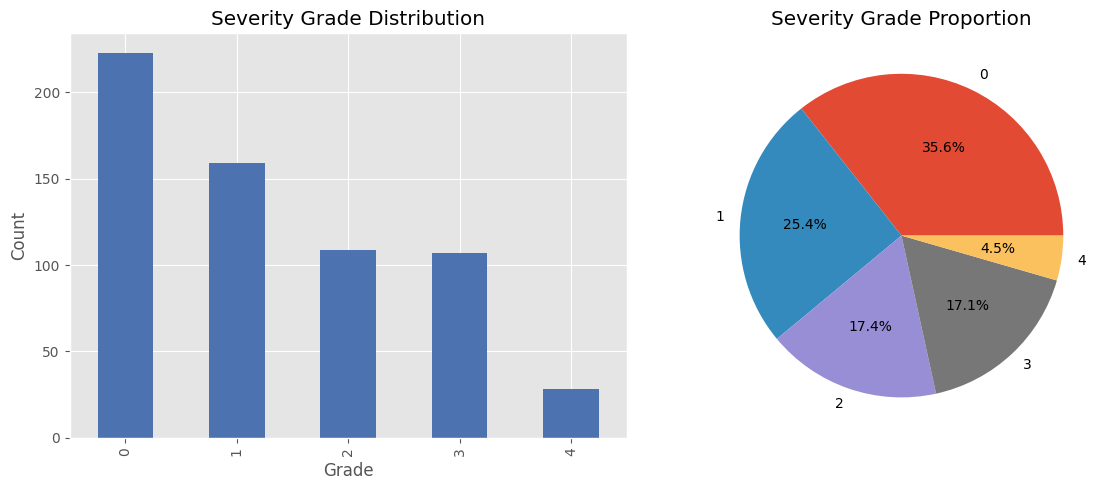


Class 4 (Critical): 28 total patients — expect ~5 in test set after split.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Severity Grade Distribution")
axes[0].set_xlabel("Grade")
axes[0].set_ylabel("Count")

y.value_counts().sort_index().plot(kind="pie", ax=axes[1], autopct="%1.1f%%")
axes[1].set_title("Severity Grade Proportion")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("13_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nClass 4 (Critical): {y.value_counts()[4]} total patients — "
      f"expect ~{int(y.value_counts()[4]*0.2)} in test set after split.")

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain distribution:\n", y_train.value_counts().sort_index())
print("\nTest distribution:\n", y_test.value_counts().sort_index())

Train shape: (500, 11)  Test shape: (126, 11)

Train distribution:
 target
0    178
1    127
2     87
3     86
4     22
Name: count, dtype: int64

Test distribution:
 target
0    45
1    32
2    22
3    21
4     6
Name: count, dtype: int64


In [6]:
# Identify which of our 11 features are categorical (binary/ordinal coded)
# vs continuous, since SMOTE-NC needs to know this to synthesize sensibly.
categorical_features = ["sex", "cp", "exang", "chol_missing", "slope_missing", "fbs"]
categorical_indices = [X_train.columns.get_loc(c) for c in categorical_features
                        if c in X_train.columns]

print("Categorical feature indices for SMOTE-NC:", categorical_indices)

smote_nc = SMOTENC(categorical_features=categorical_indices, random_state=SEED)
X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train, y_train)

print("\nBefore SMOTE-NC:", y_train.value_counts().sort_index().to_dict())
print("After SMOTE-NC :", y_train_resampled.value_counts().sort_index().to_dict())
print("\nIMPORTANT: X_test/y_test remain untouched — SMOTE-NC applied to training data only.")

Categorical feature indices for SMOTE-NC: [3, 0, 1, 4, 5, 10]

Before SMOTE-NC: {0: 178, 1: 127, 2: 87, 3: 86, 4: 22}
After SMOTE-NC : {0: 178, 1: 178, 2: 178, 3: 178, 4: 178}

IMPORTANT: X_test/y_test remain untouched — SMOTE-NC applied to training data only.


In [7]:
rf_multiclass = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf_multiclass.fit(X_train_resampled, y_train_resampled)

xgb_multiclass = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    random_state=SEED, eval_metric="mlogloss",
    num_class=5, objective="multi:softprob"
)
xgb_multiclass.fit(X_train_resampled, y_train_resampled)

print("Both models trained on SMOTE-NC-resampled training data.")

Both models trained on SMOTE-NC-resampled training data.


In [8]:
def compute_multiclass_metrics(y_true, y_pred, y_proba, model_name):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Cohen Kappa": cohen_kappa_score(y_true, y_pred),
        "Matthews Corr (MCC)": matthews_corrcoef(y_true, y_pred),
        "ROC-AUC (OvR)": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
        "Log Loss": log_loss(y_true, y_proba)
    }
    print(f"\n{'='*55}\n{model_name}\n{'='*55}")
    for k, v in metrics.items():
        print(f"{k:.<25}{v:.4f}")
    print("\nPer-class report:\n", classification_report(y_true, y_pred, zero_division=0))
    return metrics

rf_preds = rf_multiclass.predict(X_test)
rf_proba = rf_multiclass.predict_proba(X_test)
rf_metrics = compute_multiclass_metrics(y_test, rf_preds, rf_proba, "Random Forest (Multiclass)")

xgb_preds = xgb_multiclass.predict(X_test)
xgb_proba = xgb_multiclass.predict_proba(X_test)
xgb_metrics = compute_multiclass_metrics(y_test, xgb_preds, xgb_proba, "XGBoost (Multiclass)")


Random Forest (Multiclass)
Accuracy.................0.4603
Macro Precision..........0.3352
Macro Recall.............0.3323
Macro F1.................0.3292
Balanced Accuracy........0.3323
Cohen Kappa..............0.2625
Matthews Corr (MCC)......0.2649
ROC-AUC (OvR)............0.7276
Log Loss.................1.2865

Per-class report:
               precision    recall  f1-score   support

           0       0.71      0.78      0.74        45
           1       0.29      0.38      0.32        32
           2       0.37      0.32      0.34        22
           3       0.31      0.19      0.24        21
           4       0.00      0.00      0.00         6

    accuracy                           0.46       126
   macro avg       0.34      0.33      0.33       126
weighted avg       0.44      0.46      0.45       126


XGBoost (Multiclass)
Accuracy.................0.4048
Macro Precision..........0.2883
Macro Recall.............0.2883
Macro F1.................0.2881
Balanced Accuracy........

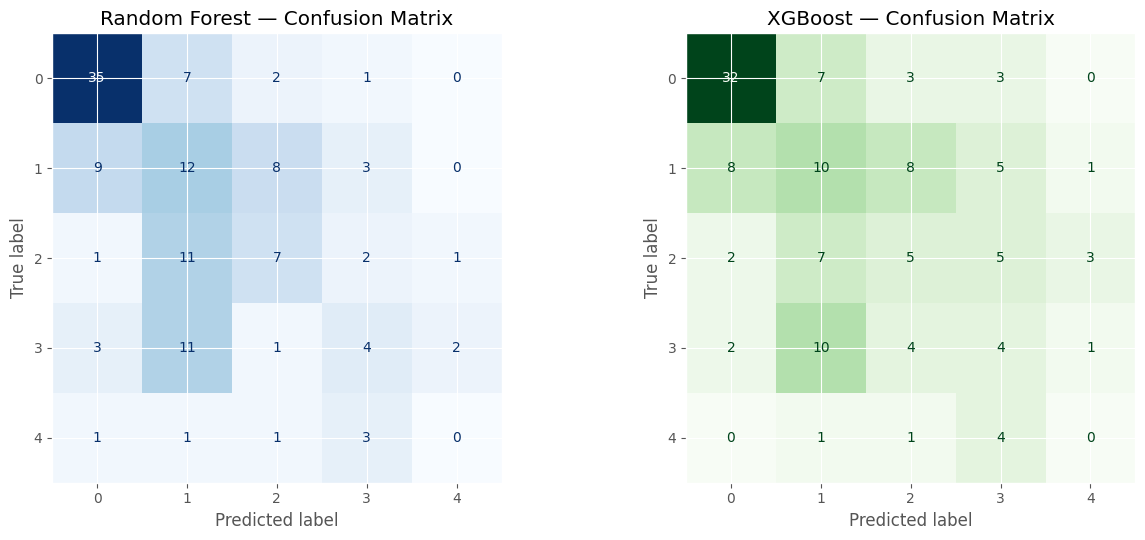

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

cm_rf = confusion_matrix(y_test, rf_preds)
cm_xgb = confusion_matrix(y_test, xgb_preds)

ConfusionMatrixDisplay(cm_rf, display_labels=[0,1,2,3,4]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Random Forest — Confusion Matrix")

ConfusionMatrixDisplay(cm_xgb, display_labels=[0,1,2,3,4]).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("XGBoost — Confusion Matrix")

plt.tight_layout()
plt.savefig("13_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

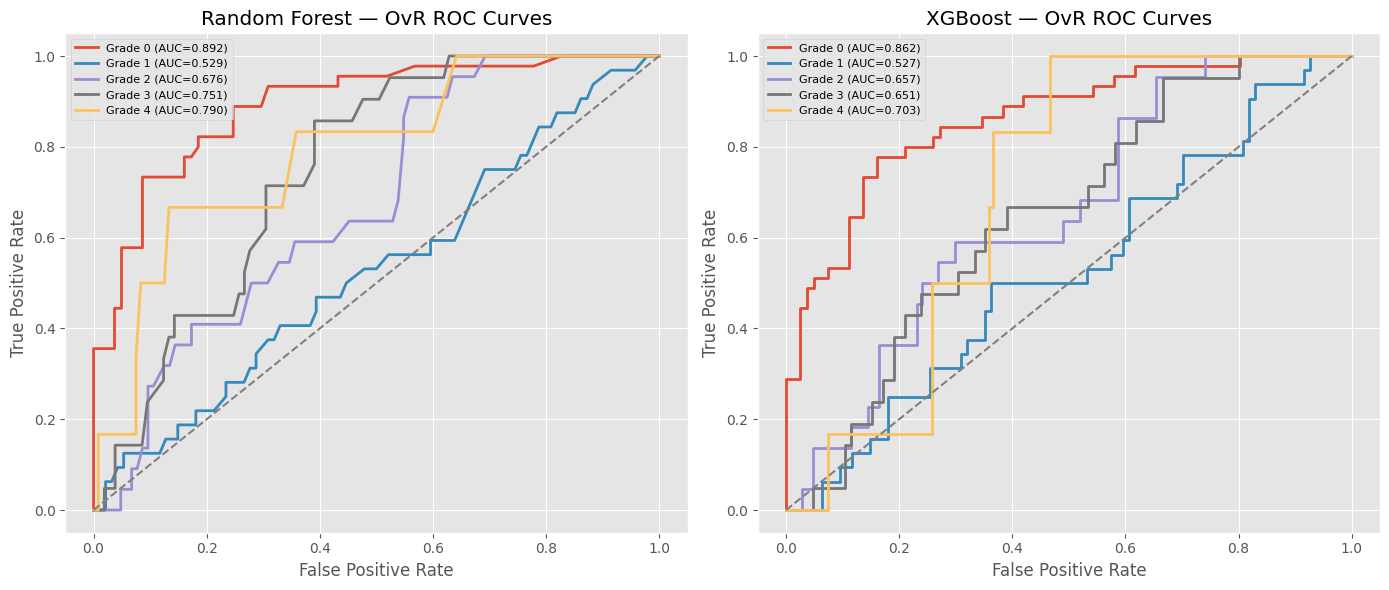

In [10]:
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, proba, name in [(axes[0], rf_proba, "Random Forest"), (axes[1], xgb_proba, "XGBoost")]:
    for class_idx in range(5):
        fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], proba[:, class_idx])
        auc_score = roc_auc_score(y_test_bin[:, class_idx], proba[:, class_idx])
        ax.plot(fpr, tpr, linewidth=2, label=f"Grade {class_idx} (AUC={auc_score:.3f})")
    ax.plot([0,1],[0,1], linestyle="--", color="gray")
    ax.set_title(f"{name} — OvR ROC Curves")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig("13_roc_curves_ovr.png", dpi=300, bbox_inches="tight")
plt.show()

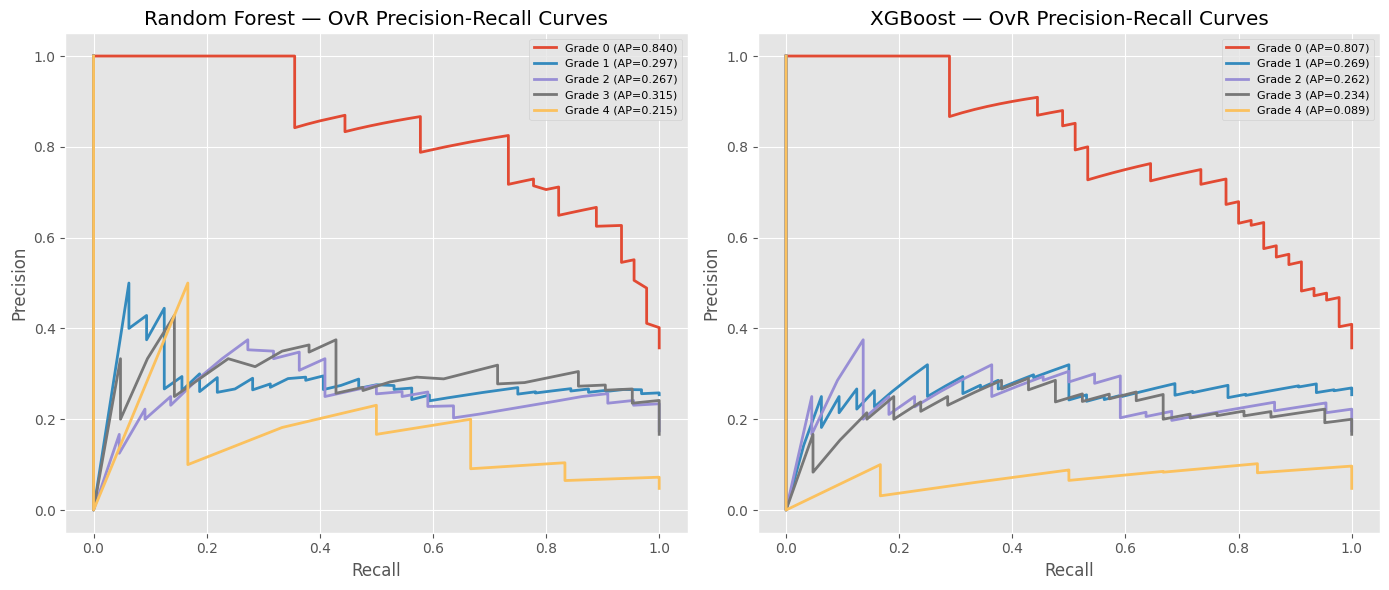

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, proba, name in [(axes[0], rf_proba, "Random Forest"), (axes[1], xgb_proba, "XGBoost")]:
    for class_idx in range(5):
        prec, rec, _ = precision_recall_curve(y_test_bin[:, class_idx], proba[:, class_idx])
        ap = average_precision_score(y_test_bin[:, class_idx], proba[:, class_idx])
        ax.plot(rec, prec, linewidth=2, label=f"Grade {class_idx} (AP={ap:.3f})")
    ax.set_title(f"{name} — OvR Precision-Recall Curves")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig("13_pr_curves_ovr.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
explainer_mc = shap.TreeExplainer(rf_multiclass)
raw_shap_mc = explainer_mc.shap_values(X_test)

print("Raw SHAP output type:", type(raw_shap_mc))
if isinstance(raw_shap_mc, list):
    print("List of", len(raw_shap_mc), "arrays, each shape:", raw_shap_mc[0].shape)
    shap_per_class = raw_shap_mc
else:
    print("Single array shape:", raw_shap_mc.shape)
    # shape (n_samples, n_features, n_classes) -> split into per-class list
    shap_per_class = [raw_shap_mc[..., c] for c in range(raw_shap_mc.shape[-1])]

Raw SHAP output type: <class 'numpy.ndarray'>
Single array shape: (126, 11, 5)


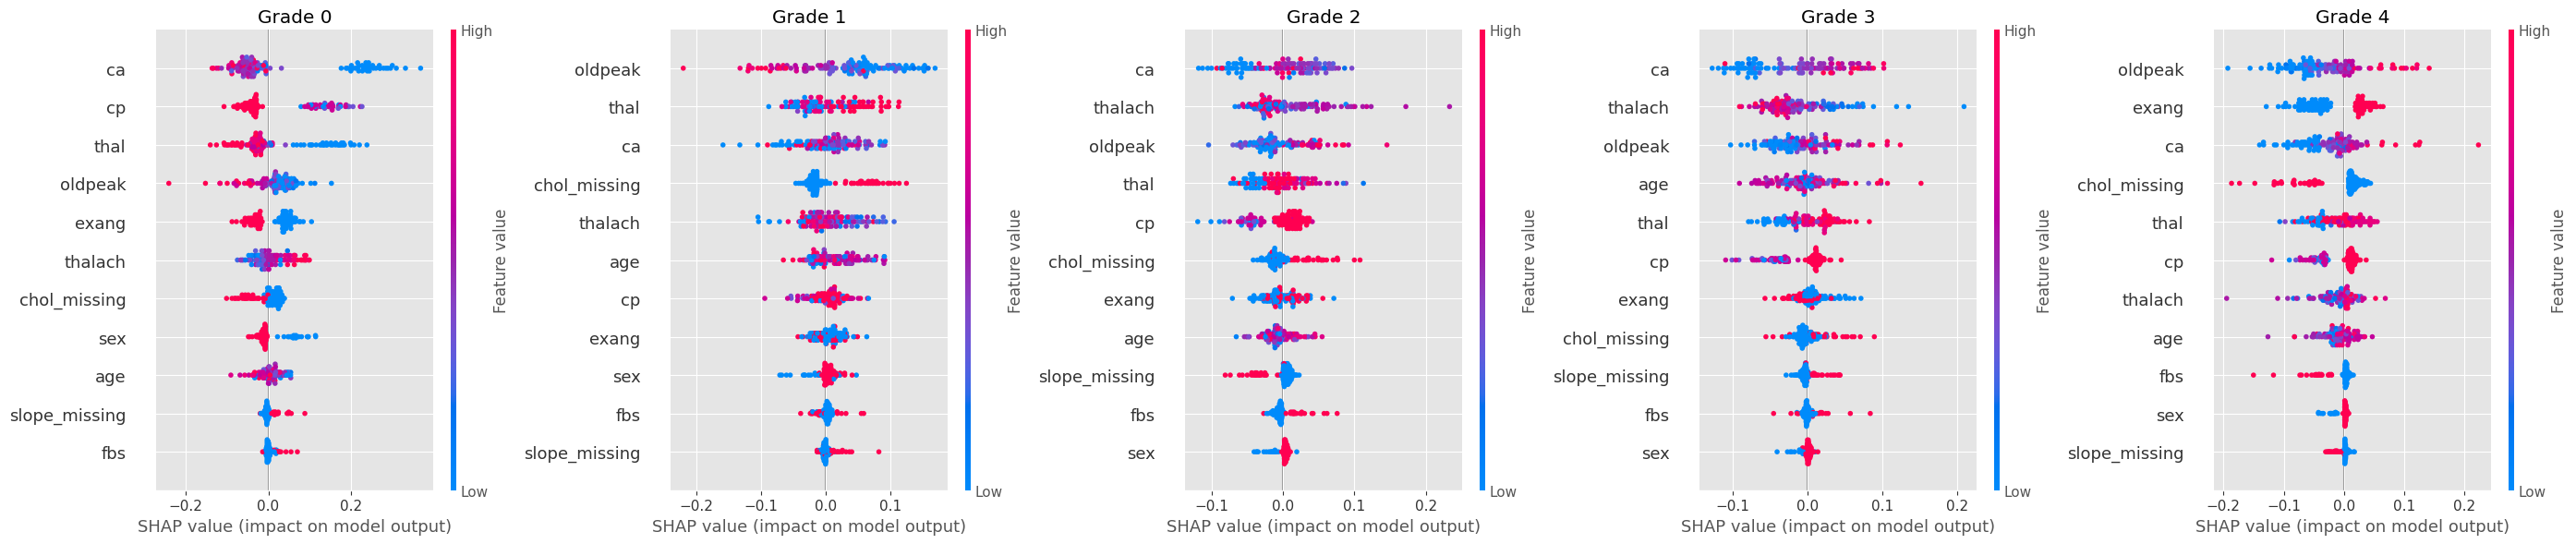

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(28, 6))
for class_idx in range(5):
    plt.sca(axes[class_idx])
    shap.summary_plot(
        shap_per_class[class_idx], X_test,
        show=False, plot_size=None
    )
    axes[class_idx].set_title(f"Grade {class_idx}")

plt.tight_layout()
plt.savefig("13_shap_summary_per_class.png", dpi=300, bbox_inches="tight")
plt.show()

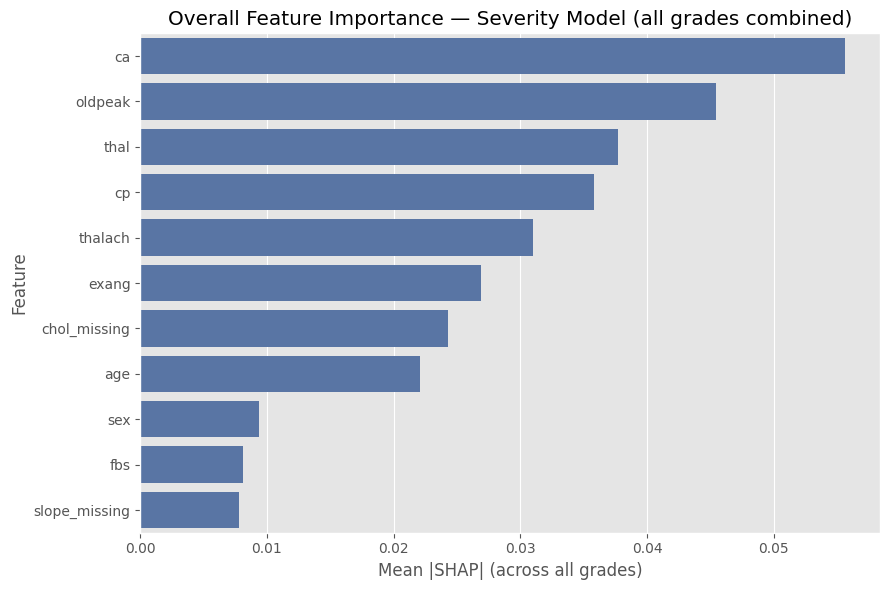

      Feature  Mean |SHAP| (across all grades)
           ca                         0.055606
      oldpeak                         0.045406
         thal                         0.037686
           cp                         0.035795
      thalach                         0.031027
        exang                         0.026896
 chol_missing                         0.024268
          age                         0.022104
          sex                         0.009373
          fbs                         0.008105
slope_missing                         0.007766


In [14]:
mean_abs_shap_all_classes = np.mean(
    [np.abs(shap_per_class[c]).mean(axis=0) for c in range(5)], axis=0
)
importance_df = pd.DataFrame({
    "Feature": SELECTED_FEATURES,
    "Mean |SHAP| (across all grades)": mean_abs_shap_all_classes
}).sort_values(by="Mean |SHAP| (across all grades)", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x="Mean |SHAP| (across all grades)", y="Feature", color="#4C72B0")
plt.title("Overall Feature Importance — Severity Model (all grades combined)")
plt.tight_layout()
plt.savefig("13_shap_bar_overall.png", dpi=300, bbox_inches="tight")
plt.show()

print(importance_df.to_string(index=False))

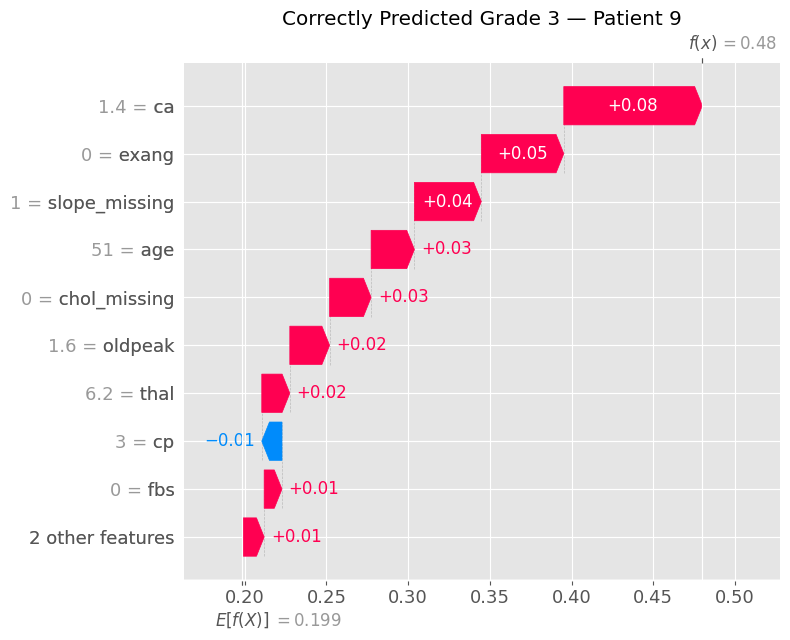

In [15]:
target_class = 4
candidates = np.where((rf_preds == target_class) & (y_test.values == target_class))[0]
if len(candidates) == 0:
    target_class = 3
    candidates = np.where((rf_preds == target_class) & (y_test.values == target_class))[0]

demo_idx = candidates[0]
row_pos = demo_idx

explanation = shap.Explanation(
    values=shap_per_class[target_class][row_pos],
    base_values=explainer_mc.expected_value[target_class] if isinstance(explainer_mc.expected_value, (list, np.ndarray)) else explainer_mc.expected_value,
    data=X_test.iloc[row_pos],
    feature_names=SELECTED_FEATURES
)

plt.figure()
shap.waterfall_plot(explanation, show=False)
plt.title(f"Correctly Predicted Grade {target_class} — Patient {demo_idx}")
plt.tight_layout()
plt.savefig("13_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
comparison_mc = pd.DataFrame({
    "Random Forest": rf_metrics,
    "XGBoost": xgb_metrics
}).round(4)

print(comparison_mc)
comparison_mc.to_csv("13_model_comparison.csv")

winner = "Random Forest" if rf_metrics["Macro F1"] >= xgb_metrics["Macro F1"] else "XGBoost"
print(f"\nWinner (by Macro F1): {winner}")

                     Random Forest  XGBoost
Accuracy                    0.4603   0.4048
Macro Precision             0.3352   0.2883
Macro Recall                0.3323   0.2883
Macro F1                    0.3292   0.2881
Balanced Accuracy           0.3323   0.2883
Cohen Kappa                 0.2625   0.2021
Matthews Corr (MCC)         0.2649   0.2022
ROC-AUC (OvR)               0.7276   0.6798
Log Loss                    1.2865   1.4825

Winner (by Macro F1): Random Forest


In [17]:
final_severity_model = rf_multiclass if winner == "Random Forest" else xgb_multiclass

joblib.dump(final_severity_model, "13_severity_rf.pkl" if winner == "Random Forest" else "13_severity_xgb.pkl")

final_metrics = rf_metrics if winner == "Random Forest" else xgb_metrics
pd.Series(final_metrics).to_csv("13_multiclass_metrics.csv")

training_history = {
    "winner": winner,
    "smote_nc_applied": True,
    "smote_nc_train_distribution_before": {0: 178, 1: 127, 2: 87, 3: 86, 4: 22},
    "smote_nc_train_distribution_after": {0: 178, 1: 178, 2: 178, 3: 178, 4: 178},
    "test_set_untouched": True,
    "class_4_test_size_caveat": "Test set contains only ~5 Grade-4 patients; per-class metrics for "
                                  "Grade 4 carry high variance regardless of model quality.",
    "calibration_applied": False,
    "calibration_rationale": "Severity model is gated behind the already-calibrated binary classifier; "
                              "a second calibration layer was judged unnecessary at this dataset scale."
}
with open("13_training_history.json", "w") as f:
    json.dump(training_history, f, indent=2)

print(f"Locked severity model: {winner}")

Locked severity model: Random Forest


In [18]:
def predict_severity_gated(binary_prediction, clinical_features_dict, severity_model, feature_order):
    """
    Only invokes the severity model if binary classifier predicted Disease.
    Returns Grade 0 immediately otherwise, with zero extra computation.
    """
    if binary_prediction == "No Disease":
        return {"severity_grade": 0, "severity_source": "binary_gate_no_disease", "severity_proba": None}

    X = pd.DataFrame([clinical_features_dict])[feature_order]
    proba = severity_model.predict_proba(X)[0]
    grade = int(severity_model.predict(X)[0])

    return {
        "severity_grade": grade,
        "severity_source": "trained_multiclass_rf",
        "severity_proba": {str(i): round(float(p), 4) for i, p in enumerate(proba)}
    }

# Quick validation against a real disease-positive test patient
demo_idx = np.where(y_test.values > 0)[0][0]
demo_patient = X_test.iloc[demo_idx].to_dict()
result = predict_severity_gated("Disease", demo_patient, final_severity_model, SELECTED_FEATURES)
print(json.dumps(result, indent=2))
print("True grade was:", y_test.iloc[demo_idx])

{
  "severity_grade": 3,
  "severity_source": "trained_multiclass_rf",
  "severity_proba": {
    "0": 0.04,
    "1": 0.03,
    "2": 0.175,
    "3": 0.395,
    "4": 0.36
  }
}
True grade was: 4


The severity classifier complements the binary disease classifier in a 
hierarchical design: binary prediction determines whether heart disease 
is present; the multiclass classifier estimates severity only for 
positive cases, gated behind that decision. This separates disease 
detection from severity estimation, improving interpretability and 
avoiding unnecessary computation for disease-free cases — mirroring how 
severity grading is used clinically (it is only meaningful once disease 
is confirmed present).

This replaces the heuristic probability-banded severity placeholder used 
in Notebook 12 with a trained model. The `severity_source` field in the 
pipeline's JSON output should now read "trained_multiclass_rf" (or xgb) 
instead of "heuristic_probability_band" once this model is wired in.

In [19]:
import shutil

os.makedirs("results13/models", exist_ok=True)
os.makedirs("results13/metrics", exist_ok=True)
os.makedirs("results13/plots", exist_ok=True)
os.makedirs("results13/manifest", exist_ok=True)

model_file = "13_severity_rf.pkl" if winner == "Random Forest" else "13_severity_xgb.pkl"
shutil.move(model_file, f"results13/models/{model_file}")

for f in ["13_multiclass_metrics.csv", "13_model_comparison.csv"]:
    if os.path.exists(f):
        shutil.move(f, f"results13/metrics/{f}")

plot_files = [
    "13_target_distribution.png", "13_confusion_matrices.png",
    "13_roc_curves_ovr.png", "13_pr_curves_ovr.png",
    "13_shap_summary_per_class.png", "13_shap_bar_overall.png", "13_waterfall.png"
]
for f in plot_files:
    if os.path.exists(f):
        shutil.move(f, f"results13/plots/{f}")

shutil.move("13_training_history.json", "results13/manifest/13_training_history.json")

manifest = {
    "notebook": "13_multiclass_severity_model",
    "winner_model": winner,
    "features_used": SELECTED_FEATURES,
    "smote_nc_applied_to": "training set only",
    "gated_integration_function": "predict_severity_gated()",
    "supersedes": "Notebook 12 heuristic severity placeholder"
}
with open("results13/manifest/13_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

shutil.make_archive("results13", "zip", "results13")
print("Notebook 13 complete. Artifacts saved to results13.zip")

Notebook 13 complete. Artifacts saved to results13.zip


## Appended: Verification + Robustness Additions

The two cells below were added after the notebook was reviewed for Phase 7 backend integration. Nothing above this point was modified — these are purely additive checks/comparisons.

1. **Dynamic verification of the SMOTE-NC manifest** — Cell 17 logs before/after class distribution as a hardcoded dict. This cell recomputes the real numbers and flags any drift.
2. **Collapsed 3-class severity robustness check** — a fallback Absent/Mild/Severe grouping, trained separately, in case the 5-class model's Grade-4 instability (n≈6 in test) becomes a blocker for the production severity field.

In [20]:
# --- POST-HOC VERIFICATION: dynamic SMOTE-NC distribution check ---
# Cell 17 logs SMOTE-NC before/after class distribution as a hardcoded
# dict, which is fragile (will silently go stale if upstream data changes).
# This cell recomputes the same numbers directly from the actual train/
# resampled splits and cross-checks them against what was logged, WITHOUT
# modifying the original cell.

actual_before = y_train.value_counts().sort_index().to_dict()
actual_after = pd.Series(y_train_resampled).value_counts().sort_index().to_dict()

print("Actual SMOTE-NC before:", actual_before)
print("Actual SMOTE-NC after :", actual_after)

logged_before = training_history["smote_nc_train_distribution_before"]
logged_after = training_history["smote_nc_train_distribution_after"]

mismatch = (actual_before != logged_before) or (actual_after != logged_after)
print("\nMismatch vs hardcoded values in training_history.json:", mismatch)
if mismatch:
    print("Logged before:", logged_before, " | Logged after:", logged_after)
    print("-> Recommend swapping the hardcoded dict in Cell 17 for these computed "
          "values directly (y_train.value_counts() / pd.Series(y_train_resampled)"
          ".value_counts()) so the manifest can't silently drift from reality.")

# Save corrected manifest alongside the original, without overwriting it
training_history_corrected = dict(training_history)
training_history_corrected["smote_nc_train_distribution_before"] = actual_before
training_history_corrected["smote_nc_train_distribution_after"] = actual_after
training_history_corrected["verified_dynamically"] = True

with open("13_training_history_verified.json", "w") as f:
    json.dump(training_history_corrected, f, indent=2)

print("\nSaved verified manifest to 13_training_history_verified.json")


Actual SMOTE-NC before: {0: 178, 1: 127, 2: 87, 3: 86, 4: 22}
Actual SMOTE-NC after : {0: 178, 1: 178, 2: 178, 3: 178, 4: 178}

Mismatch vs hardcoded values in training_history.json: False

Saved verified manifest to 13_training_history_verified.json


In [21]:
# --- ROBUSTNESS CHECK: collapsed 3-class severity grouping ---
# Grade 4 has only ~6 test patients, so its individual metric is
# high-variance regardless of model quality (flagged in Cell 0 and the
# Cell 17 caveat). This does NOT replace the 5-class model above — it
# trains a SEPARATE 3-class grouping (0=Absent, 1=Mild[grades 1-2],
# 2=Severe[grades 3-4]) on the same split/SMOTE-NC philosophy, purely as
# a fallback comparison if 5-class instability blocks production use.

def collapse_grade(g):
    if g == 0:
        return 0
    elif g in (1, 2):
        return 1
    else:
        return 2

y_train_3c = y_train.map(collapse_grade)
y_test_3c = y_test.map(collapse_grade)

smote_nc_3c = SMOTENC(categorical_features=categorical_indices, random_state=SEED)
X_train_3c_resampled, y_train_3c_resampled = smote_nc_3c.fit_resample(X_train, y_train_3c)

rf_3c = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf_3c.fit(X_train_3c_resampled, y_train_3c_resampled)

preds_3c = rf_3c.predict(X_test)
proba_3c = rf_3c.predict_proba(X_test)

metrics_3c = compute_multiclass_metrics(y_test_3c, preds_3c, proba_3c,
                                         "Random Forest (Collapsed 3-Class Severity)")

print("\nComparison — 5-class Macro F1:", round(rf_metrics["Macro F1"], 4),
      " vs 3-class Macro F1:", round(metrics_3c["Macro F1"], 4))
print("\nUse this as a fallback severity scheme (Absent/Mild/Severe) if the "
      "5-class grading remains too unstable on Grade 4 for production use. "
      "Does NOT replace 13_severity_rf.pkl above — saved separately for "
      "comparison only.")

joblib.dump(rf_3c, "13_severity_rf_3class_robustness.pkl")
pd.Series(metrics_3c).to_csv("13_3class_metrics.csv")



Random Forest (Collapsed 3-Class Severity)
Accuracy.................0.6032
Macro Precision..........0.5677
Macro Recall.............0.5605
Macro F1.................0.5618
Balanced Accuracy........0.5605
Cohen Kappa..............0.3728
Matthews Corr (MCC)......0.3742
ROC-AUC (OvR)............0.7725
Log Loss.................0.8241

Per-class report:
               precision    recall  f1-score   support

           0       0.76      0.76      0.76        45
           1       0.57      0.63      0.60        54
           2       0.38      0.30      0.33        27

    accuracy                           0.60       126
   macro avg       0.57      0.56      0.56       126
weighted avg       0.59      0.60      0.60       126


Comparison — 5-class Macro F1: 0.3292  vs 3-class Macro F1: 0.5618

Use this as a fallback severity scheme (Absent/Mild/Severe) if the 5-class grading remains too unstable on Grade 4 for production use. Does NOT replace 13_severity_rf.pkl above — saved separately fo